In [594]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [595]:
path_port_serial = "/dev/ttyUSB1"

In [596]:
#l = serial.Serial()
#l.port=path_port_serial
#l.baudrate = 115200
#l.bytesize = 8
#l.open()
#l.write(bytearray([2]))
#l.close()



In [597]:
import random as rd
import time

In [702]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
        print(f'{X[i][j]:03d}',end=' ')
    print()

In [599]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(1*(BitsPorSimbolo),1*9**(BitsPorSimbolo))
      Bin[i][j] = rd.randint(1*(BitsPorSimbolo),1*9**(BitsPorSimbolo))
  return [Ain,Bin]

In [600]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [601]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [602]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [603]:
def send_matrix(X,input,flag,k=0):
  file = open(f"teste{input}.txt","+w")
  size = X.shape[0]
  Y = np.zeros((size,size),dtype=int)
  fs_fpga2pc_rate = 5e+3
  fs_pc2fpga_rate = 15e+3
  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = 115200
  s.bytesize = 8
  #fs_pc2fpga_rate = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop

  s.open()
  s.write(bytearray([255]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([255]))
  time.sleep(1/fs_pc2fpga_rate)
  for i in range(X.shape[1]):
    for j in range(X.shape[0]):
      s.write(bytearray([X[j][i]]))
      time.sleep(1/fs_pc2fpga_rate)
  if(k):
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
  else:
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
    #for i in range(size):
    #  for j in range(size):
    #    #Y[i][j] = s.read()[0]
    #    time.sleep(1/fs_fpga2pc_rate)
  
  s.close()  
  s.close()  
  return Y
 

In [604]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
M

[array([[2, 4, 5, 1],
        [3, 5, 1, 4],
        [3, 3, 7, 4],
        [6, 4, 2, 9]]),
 array([[5, 3, 3, 8],
        [6, 8, 3, 2],
        [5, 9, 5, 8],
        [2, 1, 6, 8]])]

In [605]:
M_p = shiftMatrixSystolic(M[0],M[1])

In [606]:
M_p

[array([[0, 0, 0, 2, 4, 5, 1],
        [0, 0, 3, 5, 1, 4, 0],
        [0, 3, 3, 7, 4, 0, 0],
        [6, 4, 2, 9, 0, 0, 0]]),
 array([[0, 0, 0, 5, 6, 5, 2],
        [0, 0, 3, 8, 9, 1, 0],
        [0, 3, 3, 5, 6, 0, 0],
        [8, 2, 8, 8, 0, 0, 0]])]

In [607]:
for i in range(1):
    print("Matriz -----------------------",i,"--------------------------")
    #print(M[0]@M[1])
    #M = create_matrix(Din = 16, BitsPorSimbolo=np.log2(1))
    M_p = shiftMatrixSystolic(M[0],M[1])
    send_matrix(M_p[0],"INPUT_A1",1,k=1)
    send_matrix(M_p[1],"INPUT_B1",1,k=0)
    #rec_matrix(4)
    #rec_matrix(M[0].shape[0])
    print(M[0]@M[1])
    print(0)
#    time.sleep(10)


Matriz ----------------------- 0 --------------------------
[[ 61  84  49  72]
 [ 58  62  53  74]
 [ 76 100  77 118]
 [ 82  77  94 144]]
0


## Representação do problema 
         OPA   OPB
 ....f000776af000776a_f000776a0f00776....
 ....f001370af001370a_f001370a0f01370....
 ....f031100af031100a_f031100a0f31100....
 ....f193000af193000a_f193000a1f93000....



In [670]:
def send_matrix_rec(X,input,flag,k=0):
  file = open(f"teste{input}.txt","+w")
  fs_pc2fpga_rate = 15e+3
  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = 115200
  s.bytesize = 8
  #fs_pc2fpga_rate = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop
  size  = X.shape[0]
  s.open()
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  for i in range(X.shape[1]):
    for j in range(X.shape[0]):
      if(flag):
        s.write(bytearray([X[j][i]]))
      else:
        s.write(bytearray([0]))
      time.sleep(1/fs_pc2fpga_rate)

  s.write(bytearray([0xaa]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xaa]))
  time.sleep(1/fs_pc2fpga_rate)
  #if(k):
    #for i in range(size):
    #  for j in range(size):
    #    #Y[i][j] = s.read()[0]
    #    print(s.read()[0])
    #    #time.sleep(1/(fs_fpga2pc_rate))
    #s.close()
    #while(True):
    #  print(s.read()[0])  
    #  time.sleep(1/(fs_fpga2pc_rate))
  s.close()  

 

In [609]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
M

[array([[4, 9, 2, 4],
        [3, 5, 2, 3],
        [3, 6, 3, 4],
        [6, 1, 9, 5]]),
 array([[8, 2, 5, 8],
        [4, 9, 6, 3],
        [3, 4, 4, 8],
        [7, 6, 6, 6]])]

In [610]:
M[0].shape[1]

4

In [611]:
M[0].shape[0]

4

In [612]:
def transmitter_uart(M):
    M_p = shiftMatrixSystolic(M[0],M[1])
    send_matrix_rec(M_p[0],"INPUT_A1",1,k=0)
    send_matrix_rec(M_p[1],"INPUT_B1",1,k=1)

In [613]:
def receiver_uart(size):
    s = serial.Serial()
    s.port = path_port_serial
    s.baudrate = 115200
    s.bytesize = 8
    s.open()
    Y= np.zeros((size,size),dtype=int)
    s.write(bytearray([0xea]))
    s.write(bytearray([0xea]))
    for i in range(size):
        for j in range(size):
            Y[i][j] = serial_result = s.read()[0]
    return Y

In [735]:
for i in range(1):
    print("Matriz -----------------------",i,"--------------------------")
    #print(M[0]@M[1])
    M = create_matrix(Din =4, BitsPorSimbolo=np.log2(2))

    transmitter_uart(M)
    #time.sleep(1)
    Y = receiver_uart(M[0].shape[0])
    print("Alvo: \n")
    print_matrix(M[0]@M[1])
    print("Obtido: \n")
    print_matrix(Y)
    
    ##time.sleep(10)


Matriz ----------------------- 0 --------------------------
Alvo: 

114 131 220 148 
066 036 101 047 
072 122 145 130 
084 130 179 142 
Obtido: 

121 119 101 113 
086 103 068 072 
114 159 078 094 
122 170 097 099 


In [ ]:
for i in range(1):
    print("Matriz -----------------------",i,"--------------------------")
    #print(M[0]@M[1])
    M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
    transmitter_uart(M)
    Y = receiver_uart(M[0].shape[0])
    print("Alvo: \n")
    print_matrix(M[0]@M[1])
    print("Obtido: \n")
    print_matrix(Y)

    #time.sleep(10)


Matriz ----------------------- 0 --------------------------
Alvo: 

159 145 116 119 
124 120 103 105 
174 168 123 123 
 78  96  41  52 
Obtido: 

 89  95  69  64 
 97  79  60  62 
100 117  97  87 
126 108  80  84 


In [ ]:
a = b'\x11'
int(hex(int(a[0]))[2:])


11

In [ ]:
for i in range(2):
    print("Matriz -----------------------",i,"--------------------------")
    #M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
    M_p = shiftMatrixSystolic(M[0],M[1])
    print(M[0]@M[1])
    send_matrix(M_p[0],"INPUT_A1",1,k=1)
    send_matrix(M_p[1],"INPUT_B1",1,k=0)
    
    #time.sleep(10)


Matriz ----------------------- 0 --------------------------
[[103  36  55  75]
 [164  64  79 115]
 [ 79  28  43  62]
 [150  41  79 115]]
Matriz ----------------------- 1 --------------------------
[[103  36  55  75]
 [164  64  79 115]
 [ 79  28  43  62]
 [150  41  79 115]]


In [ ]:
M[0]

array([[4, 3, 4, 8],
       [6, 8, 8, 9],
       [5, 4, 3, 2],
       [9, 4, 6, 5]])

In [ ]:
M[1]

array([[8, 1, 6, 8],
       [1, 4, 1, 1],
       [9, 1, 1, 4],
       [4, 2, 3, 3]])

In [ ]:
M[0]@M[1]

array([[103,  36,  55,  75],
       [164,  64,  79, 115],
       [ 79,  28,  43,  62],
       [150,  41,  79, 115]])

In [ ]:
M[1]@M[0]

array([[140,  88, 106, 125],
       [ 42,  43,  45,  51],
       [ 83,  55,  71, 103],
       [ 70,  52,  59,  71]])

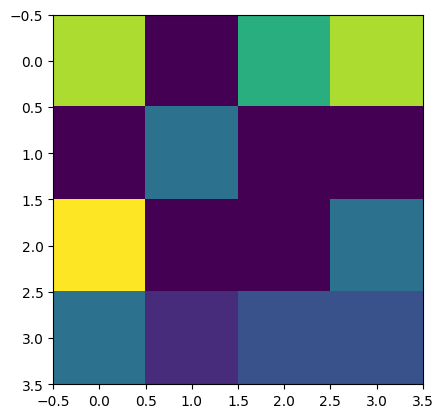

In [ ]:
plt.imshow(M[1])

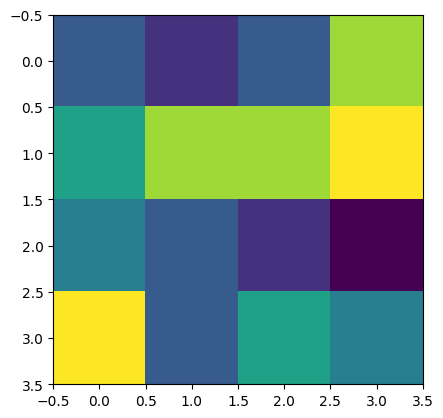

In [ ]:
plt.imshow(M[0])

In [ ]:
M[0]@M[1]

array([[103,  36,  55,  75],
       [164,  64,  79, 115],
       [ 79,  28,  43,  62],
       [150,  41,  79, 115]])

M_p = shiftMatrixSystolic(M[0],M[1])

In [ ]:
M[1]@M[0]

array([[140,  88, 106, 125],
       [ 42,  43,  45,  51],
       [ 83,  55,  71, 103],
       [ 70,  52,  59,  71]])

In [ ]:
M[0]@M[1]

array([[103,  36,  55,  75],
       [164,  64,  79, 115],
       [ 79,  28,  43,  62],
       [150,  41,  79, 115]])

In [ ]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

(array([[0, 0, 0, 4, 3, 4, 8],
        [0, 0, 6, 8, 8, 9, 0],
        [0, 5, 4, 3, 2, 0, 0],
        [9, 4, 6, 5, 0, 0, 0]]),
 array([[0, 0, 0, 4, 6, 5, 9],
        [0, 0, 3, 8, 4, 4, 0],
        [0, 4, 8, 3, 6, 0, 0],
        [8, 9, 2, 5, 0, 0, 0]]))

In [ ]:
#M = create_matrix(Din = 16, PorSimbolo=1)

In [ ]:
M[0]@M[1]

array([[103,  36,  55,  75],
       [164,  64,  79, 115],
       [ 79,  28,  43,  62],
       [150,  41,  79, 115]])

In [ ]:
M

[array([[4, 3, 4, 8],
        [6, 8, 8, 9],
        [5, 4, 3, 2],
        [9, 4, 6, 5]]),
 array([[8, 1, 6, 8],
        [1, 4, 1, 1],
        [9, 1, 1, 4],
        [4, 2, 3, 3]])]

In [ ]:
M_p[0]

array([[0, 0, 0, 4, 3, 4, 8],
       [0, 0, 6, 8, 8, 9, 0],
       [0, 5, 4, 3, 2, 0, 0],
       [9, 4, 6, 5, 0, 0, 0]])

In [ ]:
M_p[1]

array([[0, 0, 0, 4, 6, 5, 9],
       [0, 0, 3, 8, 4, 4, 0],
       [0, 4, 8, 3, 6, 0, 0],
       [8, 9, 2, 5, 0, 0, 0]])

In [674]:
def send_matrix1(X,input,flag):
  file = open(f"../teste{input}.mem","+w")
  #file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  k = 0
  file.write(f'{0XFF:02X}'+"\n")
  file.write(f'{0XFF:02X}'+"\n")
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        file.write(f'{X[j][i]:02d}'+"\n")
        #file.write(f"assign {input}[{k:03}] = "+"8'"+"h"+f'{X[j][i]:02d}'+";\n")
        k =k+1
        #strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    #print(f'{strbin:016d}',i)
   # print(int('0b'+strbin,2))
   # file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()
  file.write(f'{0XAA:02X}'+"\n")
  file.write(f'{0XAA:02X}'+"\n")
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix1(M_p[0],"INPUT_A1",0)
    send_matrix1(M_p[1],"INPUT_B1",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [675]:
M[0]@M[1]

array([[159, 145, 116, 119],
       [124, 120, 103, 105],
       [174, 168, 123, 123],
       [ 78,  96,  41,  52]])

0 0 0 4 3 4 8 
0 0 6 8 8 9 0 
0 5 4 3 2 0 0 
9 4 6 5 0 0 0 


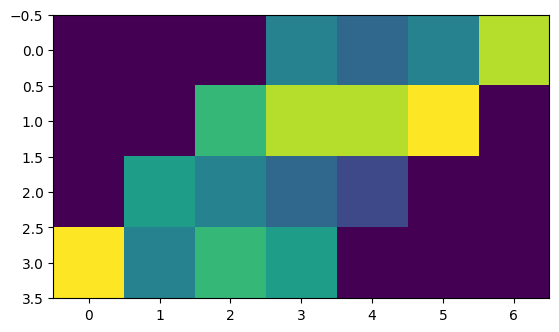

In [ ]:
print_matrix(M_p[0])
plt.imshow(M_p[0])

In [ ]:
M[0]@M[1]

array([[103,  36,  55,  75],
       [164,  64,  79, 115],
       [ 79,  28,  43,  62],
       [150,  41,  79, 115]])

In [ ]:
M_p[1]

array([[0, 0, 0, 8, 1, 9, 4],
       [0, 0, 1, 4, 1, 2, 0],
       [0, 6, 1, 1, 3, 0, 0],
       [8, 1, 4, 3, 0, 0, 0]])

In [ ]:
M_p[0]

array([[0, 0, 0, 4, 3, 4, 8],
       [0, 0, 6, 8, 8, 9, 0],
       [0, 5, 4, 3, 2, 0, 0],
       [9, 4, 6, 5, 0, 0, 0]])

In [ ]:
print_matrix(M[0]@M[1])

103 36 55 75 
164 64 79 115 
79 28 43 62 
150 41 79 115 


In [ ]:
M[0]@M[1]

array([[103,  36,  55,  75],
       [164,  64,  79, 115],
       [ 79,  28,  43,  62],
       [150,  41,  79, 115]])

In [ ]:
shiftMatrixSystolic(M[0],M[1])

[array([[0, 0, 0, 4, 3, 4, 8],
        [0, 0, 6, 8, 8, 9, 0],
        [0, 5, 4, 3, 2, 0, 0],
        [9, 4, 6, 5, 0, 0, 0]]),
 array([[0, 0, 0, 8, 1, 9, 4],
        [0, 0, 1, 4, 1, 2, 0],
        [0, 6, 1, 1, 3, 0, 0],
        [8, 1, 4, 3, 0, 0, 0]])]

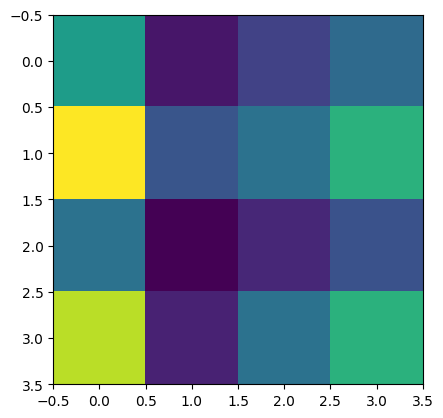

In [ ]:
plt.imshow(M[0]@M[1])

plt.show()

In [ ]:

#for i in range(100):
#    print("----------------------",i,"--------------------------")
#    M_p = shiftMatrixSystolic(M[0],M[1])
#    #Bin = M[1]
#    send_matrix(M_p[0],"INPUT_A1",0)
#    send_matrix(M_p[1],"INPUT_B1",0)
#    
#    break
#    time.sleep(10)
#
#send_matrix(Bin)

In [ ]:
M[0]

array([[4, 3, 4, 8],
       [6, 8, 8, 9],
       [5, 4, 3, 2],
       [9, 4, 6, 5]])

In [ ]:
M[1]

array([[8, 1, 6, 8],
       [1, 4, 1, 1],
       [9, 1, 1, 4],
       [4, 2, 3, 3]])

In [ ]:
M[0]@M[1]

array([[103,  36,  55,  75],
       [164,  64,  79, 115],
       [ 79,  28,  43,  62],
       [150,  41,  79, 115]])

In [ ]:
s = serial.Serial()

s.port = path_port_serial
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

In [ ]:
i =1
s.write(bytearray([int(i)]))


1

In [ ]:
serial.Serial()

Serial<id=0x7f883c5056c0, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)